# Digital Twin: Project Visualization

| No. | Name | Matric Number |
|:---:|------|:-------------:|
| 1 | FARISYA ADREA BINTI MOHAMMAD AMIN | 22011796 |
| 2 | WAN HARITH RIFQI BIN WAN MAZLI | 22011281 |
| 3 | RIZWI SHAAN MUHAMMED ALI | 24004260 |
| 4 | MUHAMMAD FARID | 24004254 |
| 5 | MOHAMMED SHAYAAN | 24004734 |

Here is a look at the Grafana visualizations for our Photodetector Digital Twin. We will be pulling real, live data from InfluxDB rather than using static mockup data

---
## 1. Why This Visualization Is Appropriate

This project's digital twin is defined as state based, rather than spatial. All the electrical and optical quantities of the photodetector are functions of time and can be termed the "state" of the photodetector. The geometry, movement and space interaction are completely abstracted and there's no physical geometry to model; instead of a 3D spatial model, we modeled a state-based twin. The true value of this project is to monitor the changes in electrical and optical parameters with time such as the bias voltage, temperature, etc.

The visualization was created with **Grafana** and queried data was retrieved from **InfluxDB** — the same time-series store that the `twin_engine` microservice stores the computed state of the digital twin into, using its function `write_to_influx()`. This ensures that the visualization is always tied to the actual system and not just a stand-alone mock-up.

---
## 2. The Dashboard

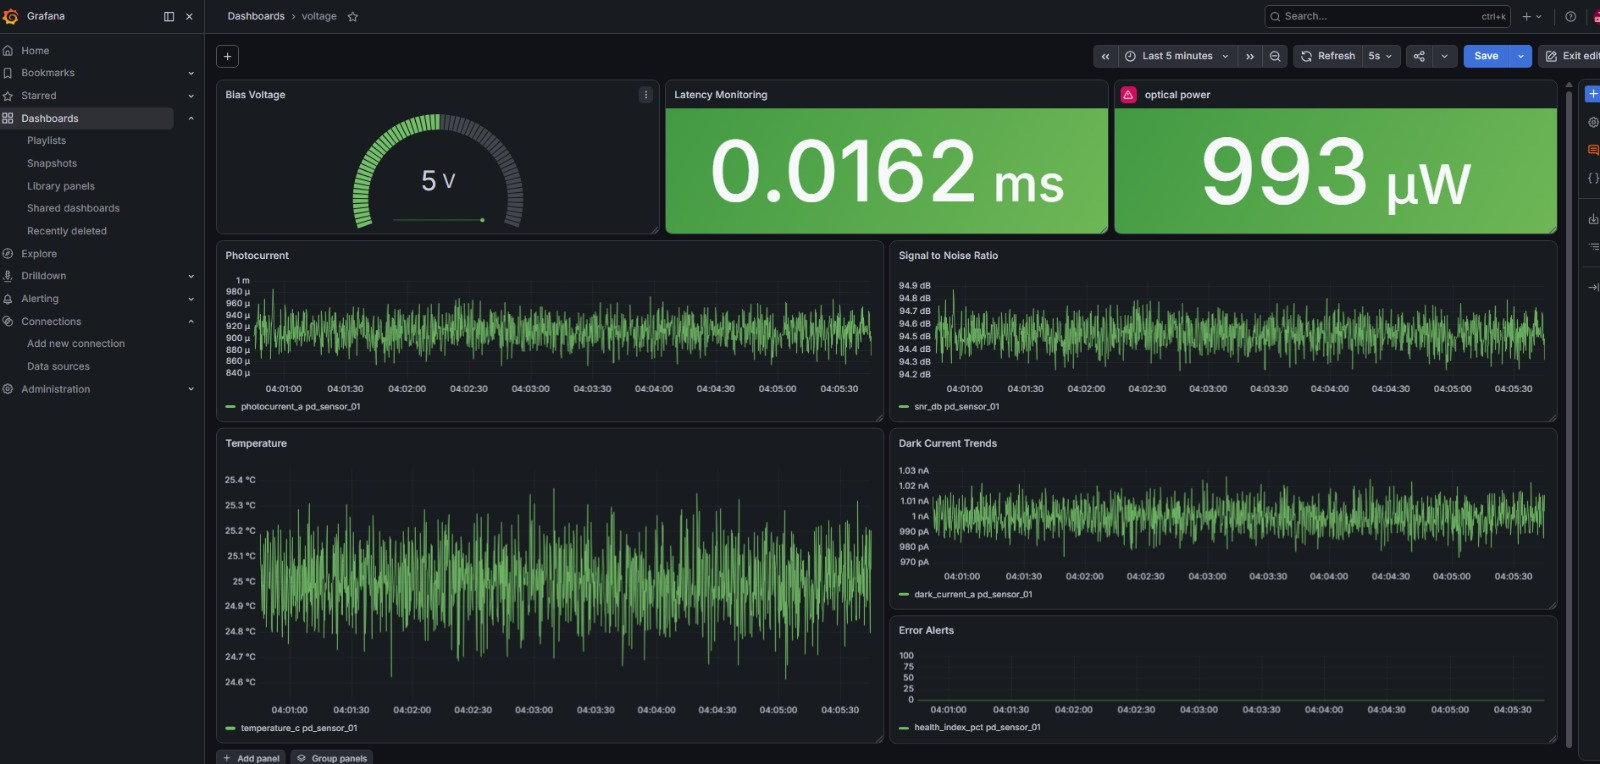
*figure 1: The live Grafana operational dashboard for the photodetector digital twin, auto-refreshing every 5 seconds over the last 5 minutes of data.*

| Panel | Digital Twin State Field | What It Shows |
|---|---|---|
| **Bias Voltage** | `bias_voltage_v` | The currently applied reverse bias, shown as a gauge (5 V baseline in this run). |
| **Latency Monitoring** | derived from ingestion timestamps | End-to-end pipeline latency, confirming the twin state is current, not stale. |
| **Optical Power** | derived: `photocurrent_a / responsivity_a_w` | Reconstructed optical input power, computed live in Flux from two stored fields (see Section 3) since raw optical power is not itself persisted to InfluxDB. |
| **Photocurrent** | `photocurrent_a` | The signal current generated by incident light, tracked over time. |
| **Signal to Noise Ratio** | `snr_db` | Real-time signal quality relative to shot noise. |
| **Temperature** | `temperature_c` | Ambient/junction temperature driving thermal drift in the physics model. |
| **Dark Current Trends** | `dark_current_a` | Thermally-driven leakage current — the key indicator of sensor health degradation. |
| **Error Alerts** | `health_index_pct` | Sensor health index; sustained values near 100% here indicate nominal operation with no degradation detected during this run. |

Every panel maps directly to a field in the digital twin state schema defined and computed by `PhotodetectorPhysicsEngine.evaluate_state()`, rather than to arbitrary or illustrative data.

---
## 3. Demonstrating Function: Verifying the Data Is Real

To prove the dashboard is driven by genuine, live data — not a static or mocked view — the same underlying InfluxDB bucket was queried directly using the **InfluxDB Data Explorer**, independently of Grafana.
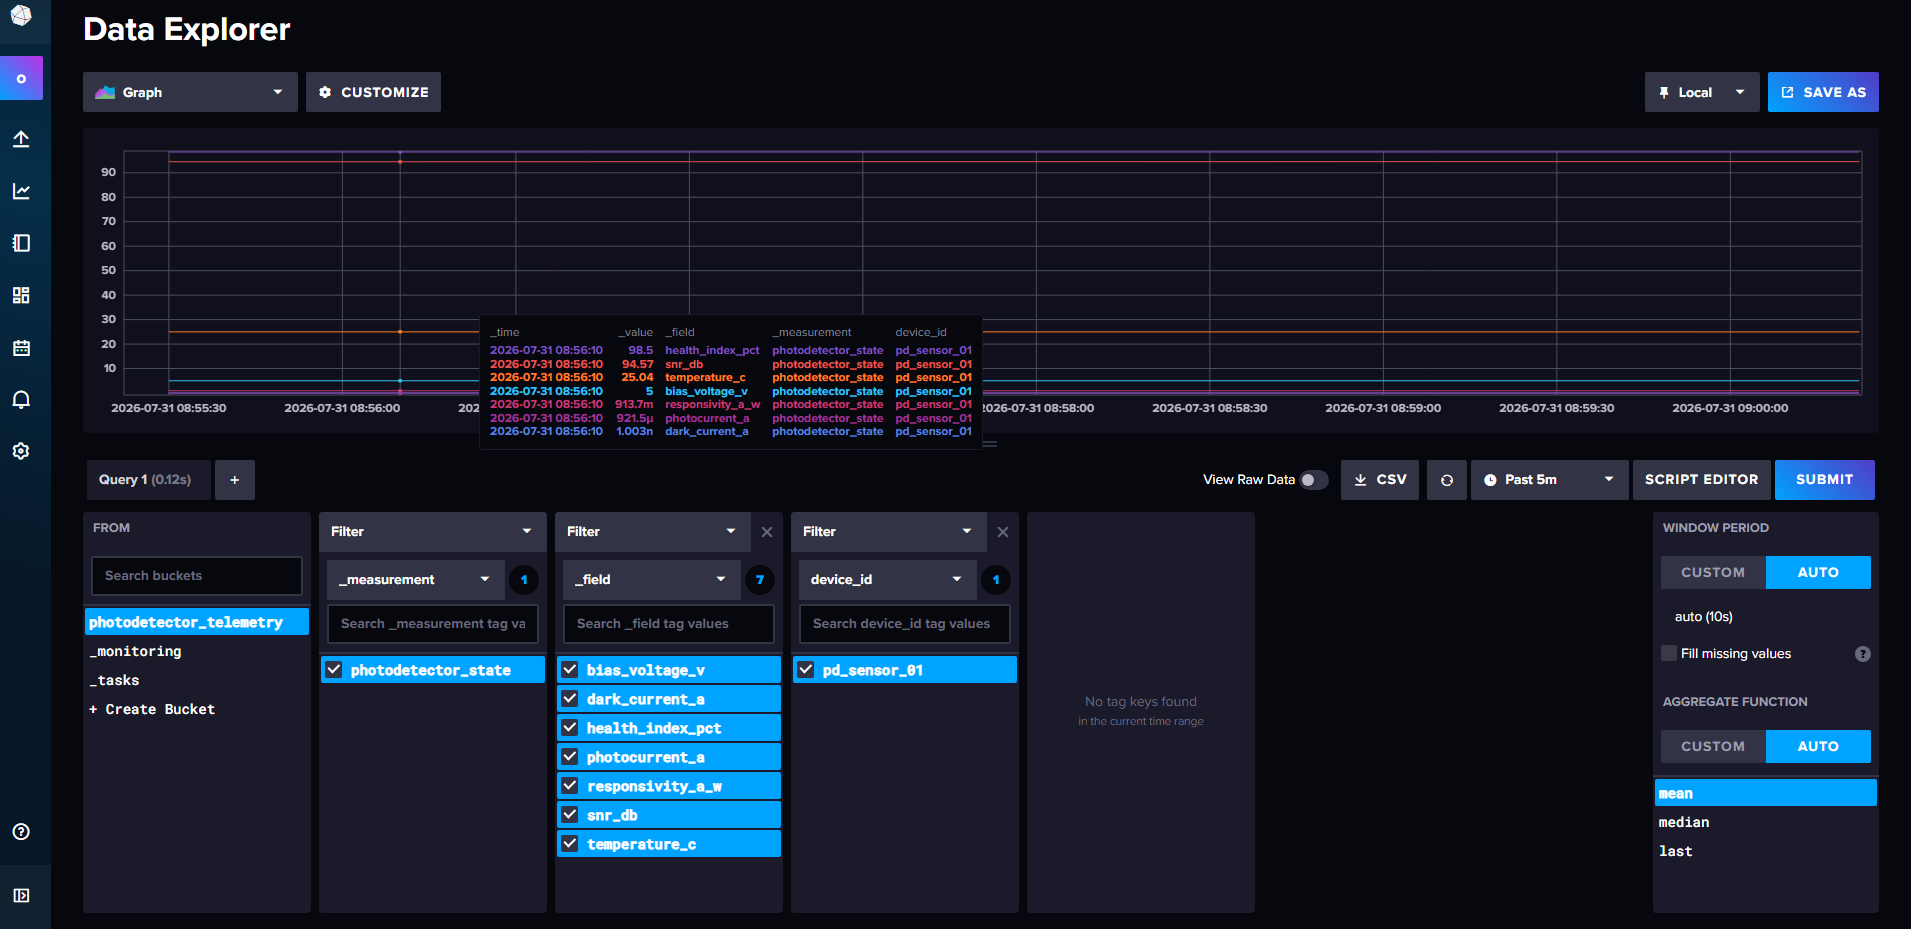

*figure 2: The InfluxDB Data Explorer querying the `photodetector_telemetry` bucket's `photodetector_state` measurement directly, with the tooltip showing individual field values at a specific timestamp (2026-07-31 08:56:10) — `health_index_pct: 98.5`, `snr_db: 94.57`, `temperature_c: 25.04`, `bias_voltage_v: 5`, `responsivity_a_w: 913.7m`, `photocurrent_a: 921.5µ`, `dark_current_a: 1.003n`.*

This confirms two things:

1. **The seven fields available in InfluxDB** (`bias_voltage_v`, `dark_current_a`, `health_index_pct`, `photocurrent_a`, `responsivity_a_w`, `snr_db`, `temperature_c`) exactly match the fields written by `twin_engine`'s `write_to_influx()` function — the dashboard is reading real, live-ingested state, not a separate or fabricated dataset.

2. **Optical power is not stored as a raw field** — it does not appear in this field list. The dashboard's "Optical Power" panel instead reconstructs it live via a Flux query that inverts the physics engine's own relationship between photocurrent, responsivity, and optical power (`photocurrent = optical_power × responsivity`, from `PhotodetectorPhysicsEngine.evaluate_state()`), computing `optical_power = photocurrent / responsivity` directly from the two fields that *are* stored. 

---
## Summary

1. **Appropriateness:** We chose a time-series dashboard (Grafana + InfluxDB) because the digital twin's state is a set of electrical/optical quantities evolving over time, not a spatial or geometric system — making a spatial simulation tool unnecessary and a telemetry dashboard the correct fit.
2. **Function:** Every dashboard panel that we decided to use for showing our work maps to a real field in the digital twin state schema computed by the physics engine, and one panel (Optical Power) demonstrates a live, physically-derived computation rather than a raw stored value.
3. **Verification:** We also did multiple attempts of cross-checking the dashboard against the InfluxDB Data Explorer confirms the visualization is reading genuine, live-ingested telemetry rather than static or mocked data.